## Imports and Helper functions

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import pdist

In [2]:
UID = "UID"
FORMULA = "Chemical"
SUCCESS = "Cat_Success"
IMPURITY = "Impurity_Percentage"
RATIO = "P2O3ratio"
ELEMENTS = ["Na", "Cu", "Fe", "Mn", "Ni"]
AMOUNT_COLS = [f"{el}_amount" for el in ELEMENTS]

# Colours: purple + orange are the main pair, green is the accent
PURPLE, ORANGE, GREEN = "#993bff", "#e55c30", "#00817f"
INK, MUTED = "#0b0b0b", "#8a8984"
CORR_CMAP = LinearSegmentedColormap.from_list("orange_purple", [ORANGE, "#fafafa", PURPLE])

In [3]:
def apply_style(os_choice="linux"):
    """os_choice: 'windows' or 'linux'."""
    from matplotlib import font_manager as fm

    if os_choice == "windows":
        base_font = "Aptos"
        math_it, math_bf, math_cal = "Helvetica:italic", "Helvetica:bold", "Helvetica:italic"
        math_sf = "Aptos"
    elif os_choice == "linux":
        base_font = "Carlito"
        math_it, math_bf, math_cal = "Nimbus Sans:italic", "Nimbus Sans:bold", "Nimbus Sans:italic"
        math_sf = "Carlito"
        for f in fm.findSystemFonts():
            if "Carlito" in f:
                fm.fontManager.addfont(f)
    else:
        raise ValueError("os_choice must be 'windows' or 'linux'")

    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "font.family": [base_font],
        "mathtext.fontset": "custom",
        "mathtext.rm": base_font,
        "mathtext.it": math_it,
        "mathtext.bf": math_bf,
        "mathtext.cal": math_cal,
        "mathtext.sf": math_sf,
        "mathtext.tt": "DejaVu Sans Mono",
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "axes.linewidth": 1.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "legend.frameon": False,
        "legend.handlelength": 2,
        "legend.handletextpad": 0.5,
        "figure.dpi": 100,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "figure.facecolor": "#fafafa",
        "axes.facecolor": "#fafafa",
    })


apply_style("linux")

In [4]:
def _no_minor_x(ax):
    """Categorical x-axes (bars, levels) shouldn't get minor ticks."""
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)


def _is_success(v):
    """Cat_Success may be bool, number or string."""
    if isinstance(v, str):
        return v.strip().lower() in {"successful", "success", "true", "1", "yes"}
    try:
        return bool(v) and not pd.isna(v)
    except TypeError:
        return False


def prepare(df):
    """Add the two flags every plot uses: is_u00 and success (bool)."""
    df = df.copy()
    df["is_u00"] = df[UID].astype(str).str.startswith("U00")
    df["success"] = df[SUCCESS].apply(_is_success)
    return df


def _u00(df):
    return df[df["is_u00"]]


def _u00_success(df):
    u = _u00(df)
    return u[u["success"]]

## Load data

In [5]:
df = pd.read_csv("dataset_splits/featurised_clean.csv")
with open("dataset_splits/feature_cols.json") as f:
    feat_cols = json.load(f)

df = prepare(df)

missing = [c for c in [IMPURITY, RATIO, "Time"] + AMOUNT_COLS if c not in df.columns]
assert not missing, f"Columns not found: {missing}"

print(f"{len(df)} rows | U00 {df['is_u00'].sum()} | A00 {(~df['is_u00']).sum()} | "
      f"{len(feat_cols)} features")

557 rows | U00 369 | A00 188 | 142 features


## Target distributions

Impurity (successful U00): min 2.65%, median 53.12%, max 84.95%


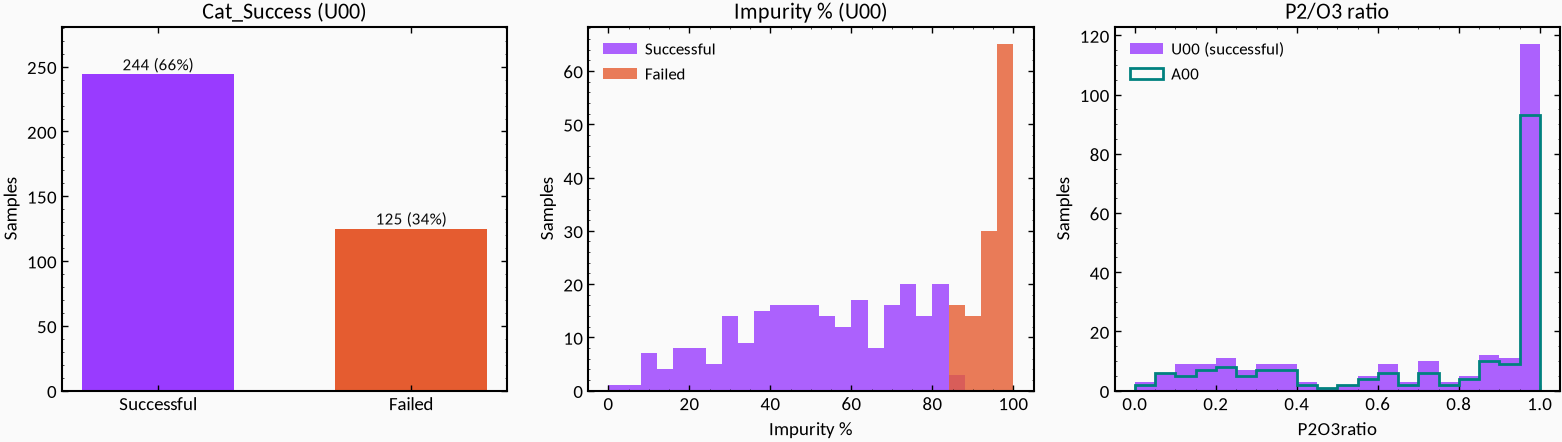

In [6]:
def target_overview(df):
    """Class balance, impurity histogram, P2/O3 histogram (U00 vs A00)."""
    u = _u00(df)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    # Cat_Success balance (U00 only - A00 are successful by construction)
    counts = u["success"].value_counts().reindex([True, False], fill_value=0)
    ax = axes[0]
    bars = ax.bar(["Successful", "Failed"], counts.values, color=[PURPLE, ORANGE], width=0.6)
    for b, n in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, n, f"{n} ({n / counts.sum():.0%})",
                ha="center", va="bottom", fontsize=12, color=INK)
    ax.set_ylim(0, counts.max() * 1.15)
    ax.set_title("Cat_Success (U00)")
    ax.set_ylabel("Samples")
    _no_minor_x(ax)

    # Impurity %, split by success - shows any spike at 100 % for failures
    ax = axes[1]
    bins = np.linspace(0, 100, 26)
    ax.hist(u.loc[u["success"], IMPURITY].dropna(), bins=bins, color=PURPLE,
            alpha=0.8, label="Successful")
    ax.hist(u.loc[~u["success"], IMPURITY].dropna(), bins=bins, color=ORANGE,
            alpha=0.8, label="Failed")
    ax.set_title("Impurity % (U00)")
    ax.set_xlabel("Impurity %")
    ax.set_ylabel("Samples")
    ax.legend()

    succ_imp = u.loc[u["success"], IMPURITY]
    print(f"Impurity (successful U00): min {succ_imp.min():.2f}%, "
          f"median {succ_imp.median():.2f}%, max {succ_imp.max():.2f}%")

    # P2/O3 ratio, U00 vs A00
    ax = axes[2]
    bins = np.linspace(0, 1, 21)
    ax.hist(u.loc[u["success"], RATIO].dropna(), bins=bins, color=PURPLE,
            alpha=0.8, label="U00 (successful)")
    ax.hist(df.loc[~df["is_u00"], RATIO].dropna(), bins=bins, color=GREEN,
            histtype="step", linewidth=2, label="A00")
    ax.set_title("P2/O3 ratio")
    ax.set_xlabel("P2O3ratio")
    ax.set_ylabel("Samples")
    ax.legend()

    fig.tight_layout()
    return fig


fig = target_overview(df)

## Targets vs synthesis parameters

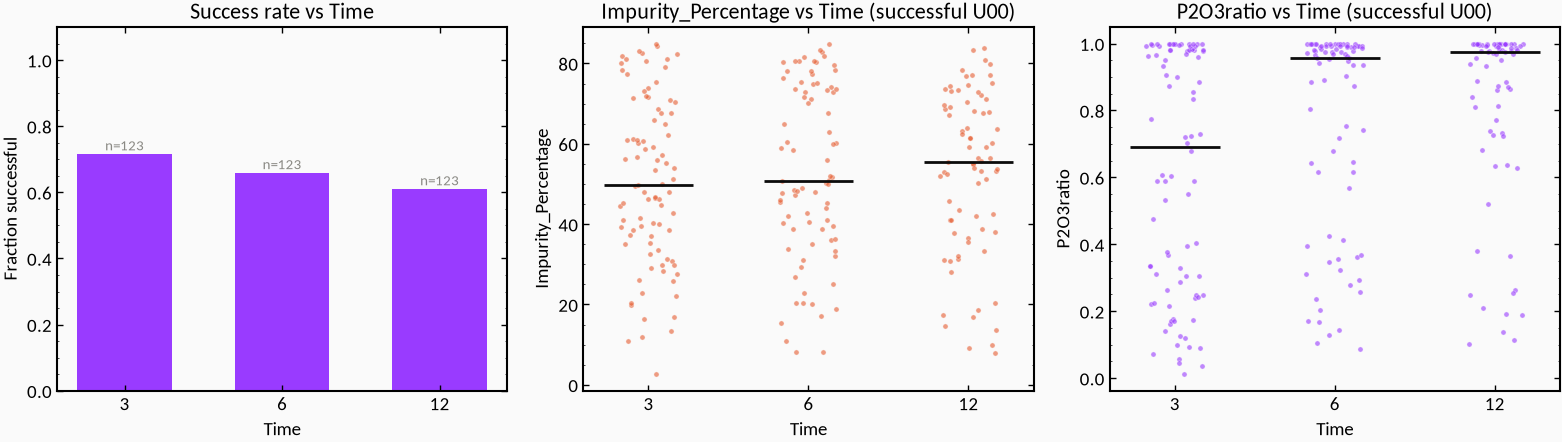

In [7]:
def targets_vs_condition(df, condition="Time"):
    """Success rate, impurity and P2/O3 ratio against one parameter with discrete levels."""
    u = _u00(df)
    levels = sorted(u[condition].dropna().unique())
    labels = [f"{l:g}" for l in levels]
    x = np.arange(len(levels))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    # Success rate per level, with n annotated
    rate = u.groupby(condition)["success"].agg(["mean", "size"]).reindex(levels)
    ax = axes[0]
    ax.bar(x, rate["mean"], color=PURPLE, width=0.6)
    for xi, (m, n) in zip(x, rate.values):
        ax.text(xi, m, f"n={int(n)}", ha="center", va="bottom", fontsize=11, color=MUTED)
    ax.set_xticks(x, labels)
    _no_minor_x(ax)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Success rate vs {condition}")
    ax.set_xlabel(condition)
    ax.set_ylabel("Fraction successful")

    # Impurity and ratio (successful only): jittered points + median line
    rng = np.random.default_rng(0)
    s = u[u["success"]]
    for ax, col, colour in [(axes[1], IMPURITY, ORANGE), (axes[2], RATIO, PURPLE)]:
        for xi, lvl in enumerate(levels):
            vals = s.loc[s[condition] == lvl, col].dropna()
            ax.scatter(xi + rng.uniform(-0.18, 0.18, len(vals)), vals, s=14,
                       color=colour, alpha=0.6, edgecolor="white", linewidth=0.4)
            if len(vals):
                ax.hlines(vals.median(), xi - 0.28, xi + 0.28, color=INK, linewidth=2)
        ax.set_xticks(x, labels)
        _no_minor_x(ax)
        ax.set_title(f"{col} vs {condition} (successful U00)")
        ax.set_xlabel(condition)
        ax.set_ylabel(col)

    fig.tight_layout()
    return fig


fig = targets_vs_condition(df, "Time")

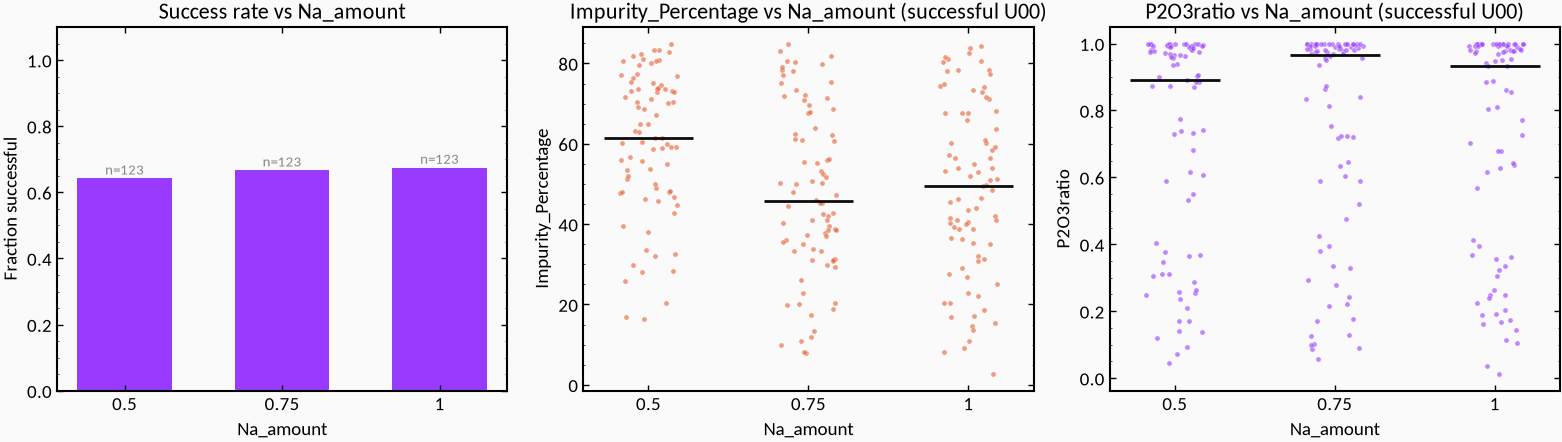

In [8]:
fig = targets_vs_condition(df, "Na_amount")

## Are the two regression targets related?

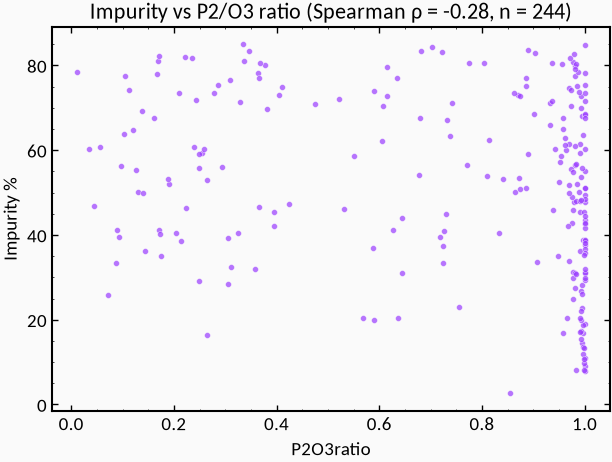

In [9]:
def impurity_vs_ratio(df):
    """Impurity % vs P2/O3 ratio for successful U00 samples."""
    s = _u00_success(df).dropna(subset=[IMPURITY, RATIO])
    rho = s[[IMPURITY, RATIO]].corr(method="spearman").iloc[0, 1]

    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.scatter(s[RATIO], s[IMPURITY], s=18, color=PURPLE, alpha=0.7,
               edgecolor="white", linewidth=0.4)
    ax.set_xlabel("P2O3ratio")
    ax.set_ylabel("Impurity %")
    ax.set_title(f"Impurity vs P2/O3 ratio (Spearman ρ = {rho:.2f}, n = {len(s)})")
    fig.tight_layout()
    return fig


fig = impurity_vs_ratio(df)

## Repeat-synthesis noise R² ceiling

In [10]:
def _repeat_groups(data, col, group_cols):
    """Rows of `data` belonging to groups with more than one non-NaN `col` value."""
    d = data.dropna(subset=[col])
    sizes = d.groupby(list(group_cols))[col].transform("size")
    return d[sizes > 1]


def _pooled_within(repeated, col, group_cols):
    """Pooled within-group variance (each group weighted by n - 1).
    Returns (pooled_var, n_groups, n_samples)."""
    grp = repeated.groupby(list(group_cols))[col]
    dof = grp.size() - 1
    pooled = (grp.var(ddof=1) * dof).sum() / dof.sum() if dof.sum() > 0 else np.nan
    return pooled, int(grp.ngroups), int(len(repeated))


def noise_ceiling(df, targets=(IMPURITY, RATIO), condition="Time"):
    """R² ceiling per target, grouping repeats by composition, and by composition + condition.

    If the second ceiling is clearly higher, the condition explains part of
    the repeat spread, so it belongs in the model as a feature.
    """
    s = _u00_success(df)
    rows = []
    for col in targets:
        total = s[col].var(ddof=1)
        for label, groups in [("composition", [FORMULA]),
                              (f"composition + {condition}", [FORMULA, condition])]:
            rep = _repeat_groups(s, col, groups)
            within, n_g, n_s = _pooled_within(rep, col, groups)
            rows.append({
                "target": col,
                "grouped_by": label,
                "n_groups": n_g,
                "n_samples": n_s,
                "within_var": within,
                "total_var": total,
                "R2_ceiling": 1 - within / total if total > 0 else np.nan,
            })
    return pd.DataFrame(rows)


def repeat_noise(df, targets=(IMPURITY, RATIO), group_cols=(FORMULA,), color_by="Time"):
    """Spread of each target across repeat syntheses (successful U00 only)."""
    group_cols = list(group_cols)
    by = group_cols[0] if len(group_cols) == 1 else group_cols   # avoids the pandas warning

    s = _u00_success(df)
    use_colour = color_by is not None and color_by in s.columns and color_by not in group_cols

    fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5))
    axes = np.atleast_1d(axes)
    if use_colour:
        norm = plt.Normalize(s[color_by].min(), s[color_by].max())
        cmap = plt.get_cmap("plasma")

    for ax, col in zip(axes, targets):
        repeated = _repeat_groups(s, col, group_cols)
        within, n_g, _ = _pooled_within(repeated, col, group_cols)
        total = s[col].var(ddof=1)
        ceiling = 1 - within / total if total > 0 else np.nan

        # sort groups by their mean, then draw one column per group
        groups = sorted(repeated.groupby(by), key=lambda kv: kv[1][col].mean())
        for i, (_, rows) in enumerate(groups):
            v = rows[col]
            ax.plot([i, i], [v.min(), v.max()], color=MUTED, linewidth=1, zorder=1)
            colour = cmap(norm(rows[color_by].values)) if use_colour else PURPLE
            ax.scatter([i] * len(v), v, s=16, c=colour, edgecolor="white",
                       linewidth=0.3, zorder=3)

        ax.set_xticks([])
        _no_minor_x(ax)
        ax.set_xlabel(f"Repeated groups (n = {n_g}), sorted by mean")
        ax.set_ylabel(col)
        ax.set_title(f"{col}: R² ceiling ≈ {ceiling:.2f}")

    if use_colour:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(sm, ax=list(axes), shrink=0.85, pad=0.01, label=color_by)
    else:
        fig.tight_layout()
    return fig


noise_ceiling(df).round(3)

,target,grouped_by,n_groups,n_samples,within_var,total_var,R2_ceiling
0,Impurity_Percentage,composition,81,229,164.542,438.563,0.625
1,Impurity_Percentage,composition + Time,0,0,NaN,438.563,NaN
2,P2O3ratio,composition,81,229,0.031,0.108,0.709
3,P2O3ratio,composition + Time,0,0,NaN,0.108,NaN


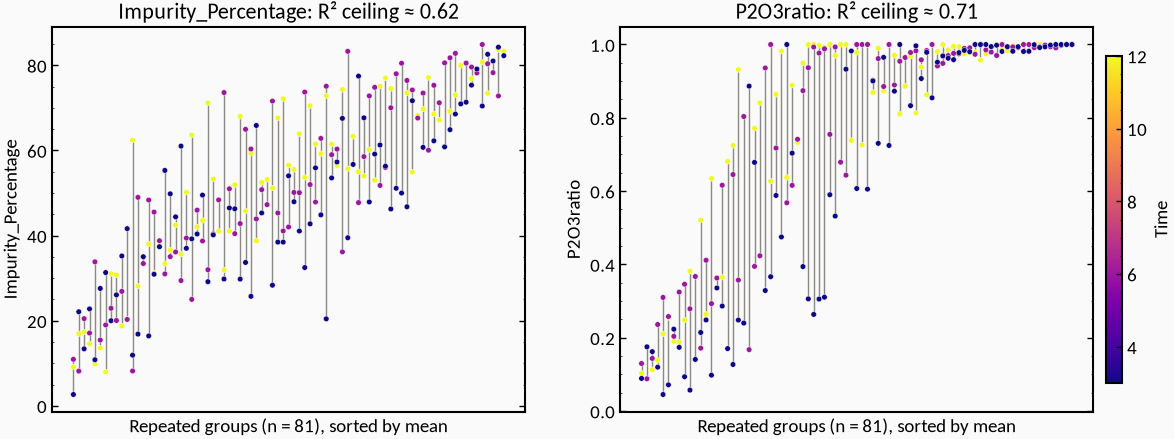

In [11]:
fig = repeat_noise(df)

## Feature correlations

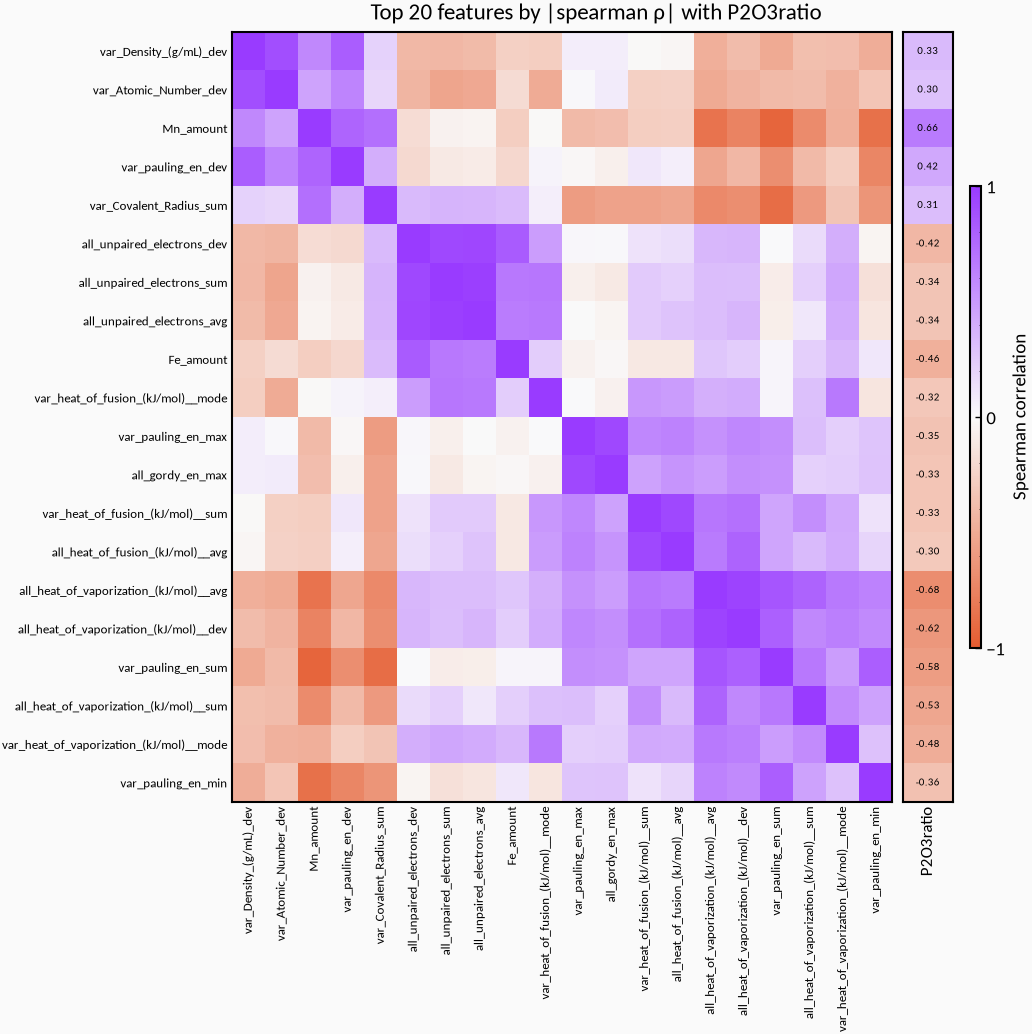

In [12]:
def _clustering_pass(corr):
    """One round of hierarchical clustering on a correlation matrix.
    Returns (labels, sizes, reordered corr)."""
    if corr.shape[0] < 3:
        return np.ones(corr.shape[0], dtype=int), {1: corr.shape[0]}, corr
    d = pdist(corr.values)
    if d.max() == 0:
        return np.ones(corr.shape[0], dtype=int), {1: corr.shape[0]}, corr
    L = sch.linkage(d, method="complete")
    labels = sch.fcluster(L, 0.5 * d.max(), "distance")
    order = np.argsort(labels, kind="stable")
    cols = corr.columns[order]
    unique, counts = np.unique(labels, return_counts=True)
    return labels, dict(zip(unique, counts)), corr.loc[cols, cols]


def cluster_layer(corr, cluster_th=4, max_level=3, level=1):
    """Recursively re-cluster any cluster bigger than `cluster_th`."""
    labels, sizes, corr = _clustering_pass(corr)
    if level >= max_level:
        return corr
    cols, i = [], 0
    for lab in sorted(sizes):              # sorted: blocks are in label order
        j = i + sizes[lab]
        block = corr.iloc[i:j, i:j]
        if sizes[lab] > cluster_th:
            block = cluster_layer(block, cluster_th, max_level, level + 1)
        cols.extend(block.columns)
        i = j
    return corr.loc[cols, cols]


def top_features(df, feat_cols, target, top=20, method="spearman"):
    """Top `top` features by |correlation| with `target` (successful U00 only)."""
    s = _u00_success(df).dropna(subset=[target])
    rho = s[feat_cols].corrwith(s[target].astype(float), method=method).dropna()
    return rho.reindex(rho.abs().sort_values(ascending=False).index)[:top]


def clustered_corr(df, feat_cols, target=None, top=20, cluster_th=4, max_level=3,
                   method="spearman", cluster_on_abs=False, size=None):
    """Clustered feature-feature correlation matrix.

    target=None: all of feat_cols.
    target=RATIO / IMPURITY: only the `top` features most correlated with it,
    plus a side strip showing each feature's correlation with the target.
    Returns (fig, ordered_corr).
    """
    if target is not None:
        rho = top_features(df, feat_cols, target, top, method)
        feat_cols = rho.index.tolist()

    X = _u00(df).drop_duplicates(subset=FORMULA)[feat_cols]
    corr = X.corr(method=method).fillna(0)
    basis = corr.abs() if cluster_on_abs else corr
    order = cluster_layer(basis, cluster_th, max_level).columns
    ordered = corr.loc[order, order]
    n = ordered.shape[0]

    if size is None:
        size = min(0.3 * n + 4, 18)
    if target is not None:
        fig, (ax, ax_t) = plt.subplots(
            1, 2, figsize=(size + 1.2, size),
            sharey=True, gridspec_kw={"width_ratios": [n, 1.5], "wspace": 0.03})
    else:
        fig, ax = plt.subplots(figsize=(size, size))

    im = ax.imshow(ordered.values, cmap=CORR_CMAP, vmin=-1, vmax=1, aspect="auto")
    ax.minorticks_off()
    ax.tick_params(top=False, right=False, length=0)
    ax.set_xticks(range(n), ordered.columns, rotation=90, fontsize=9)
    ax.set_yticks(range(n), ordered.index, fontsize=9)

    if target is not None:
        strip = rho.reindex(order).values[:, None]
        ax_t.imshow(strip, cmap=CORR_CMAP, vmin=-1, vmax=1, aspect="auto")
        for k, r in enumerate(strip[:, 0]):
            ax_t.text(0, k, f"{r:.2f}", ha="center", va="center", fontsize=8)
        ax_t.set_xticks([0], [target], rotation=90, fontsize=12)
        ax_t.tick_params(axis="y", left=False, labelleft=False)
        ax_t.minorticks_off()
        ax_t.tick_params(top=False, right=False, length=0)
        title = f"Top {n} features by |{method} ρ| with {target}"
    else:
        title = "Feature correlation (hierarchically clustered)"

    fig.colorbar(im, ax=fig.axes, ticks=[-1, 0, 1], aspect=40, shrink=0.6, pad=0.02,
                 label=f"{method.capitalize()} correlation")
    fig.suptitle(title, y=0.91, x=0.45)
    return fig, ordered


fig, ordered_ratio = clustered_corr(df, feat_cols, target=RATIO)

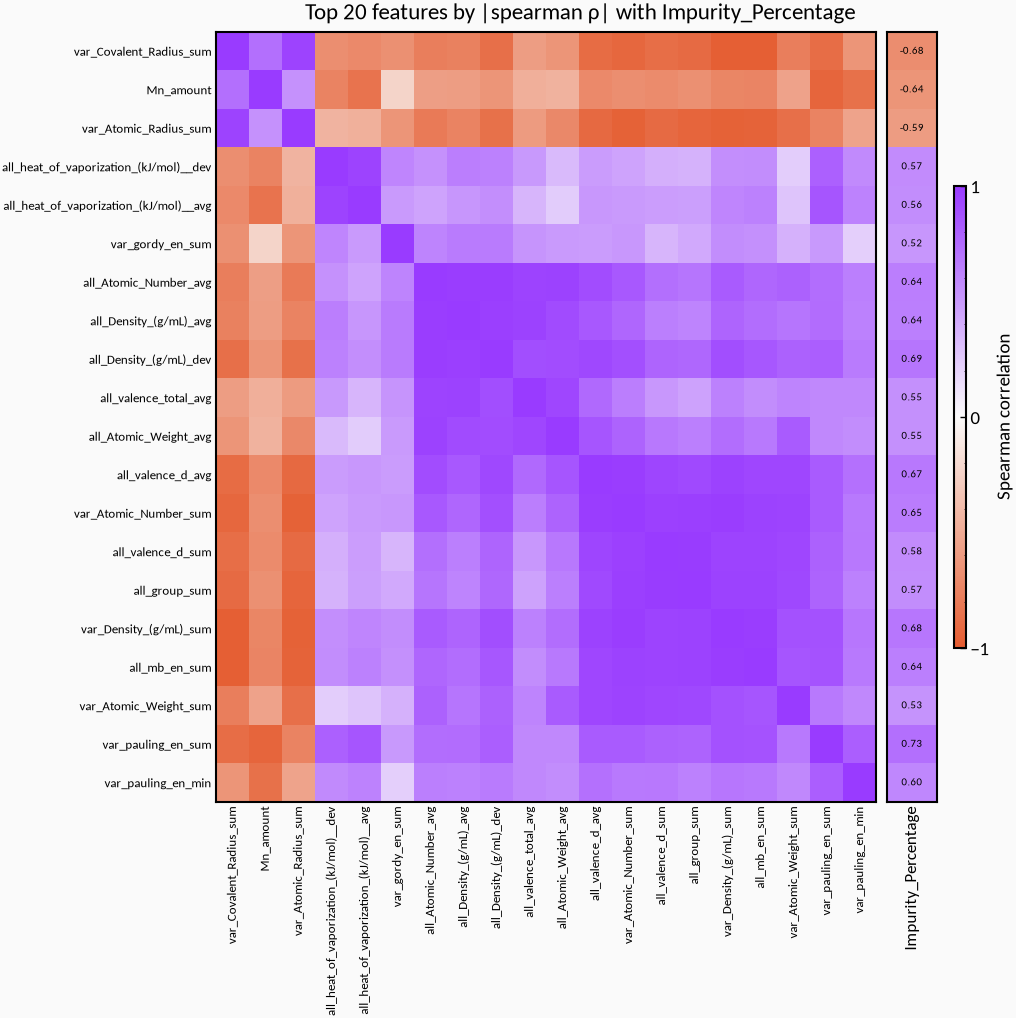

In [13]:
fig, ordered_imp = clustered_corr(df, feat_cols, target=IMPURITY)

## Element amounts vs targets

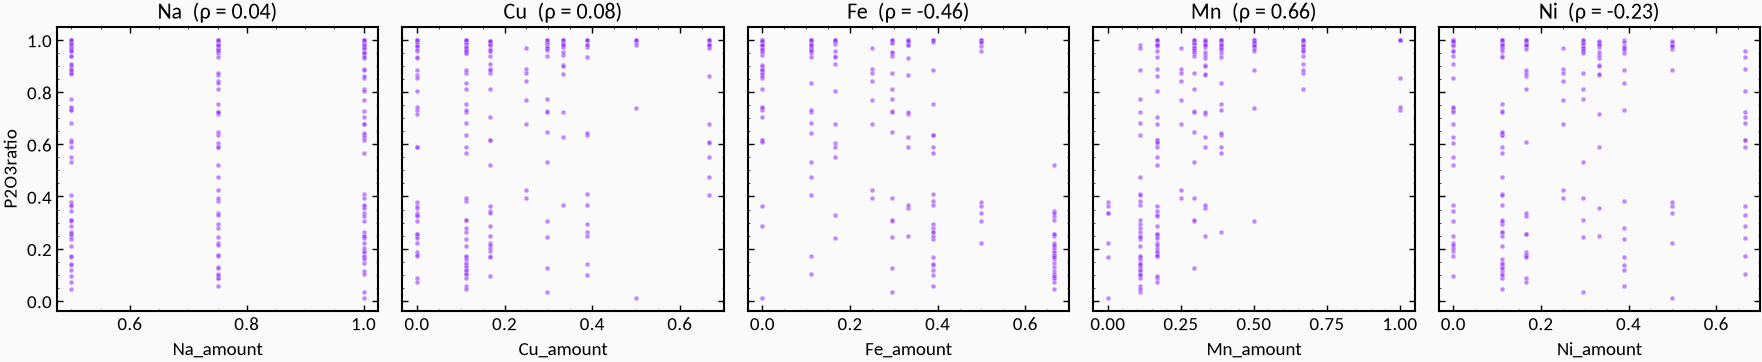

In [14]:
def amounts_vs_target(df, target=RATIO, successful_only=True):
    """One panel per element amount against the target (U00 only)."""
    u = _u00(df)
    if successful_only and target != "success":
        u = u[u["success"]]
    y = u[target].astype(float)

    fig, axes = plt.subplots(1, len(AMOUNT_COLS), figsize=(3.6 * len(AMOUNT_COLS), 4),
                             sharey=True)
    for ax, c in zip(axes, AMOUNT_COLS):
        ax.scatter(u[c], y, s=12, color=PURPLE, alpha=0.6, edgecolor="white", linewidth=0.3)
        rho = u[c].corr(y, method="spearman")
        ax.set_title(f"{c.split('_')[0]}  (ρ = {rho:.2f})")
        ax.set_xlabel(c)
    axes[0].set_ylabel(target)
    fig.tight_layout()
    return fig


fig = amounts_vs_target(df, RATIO)

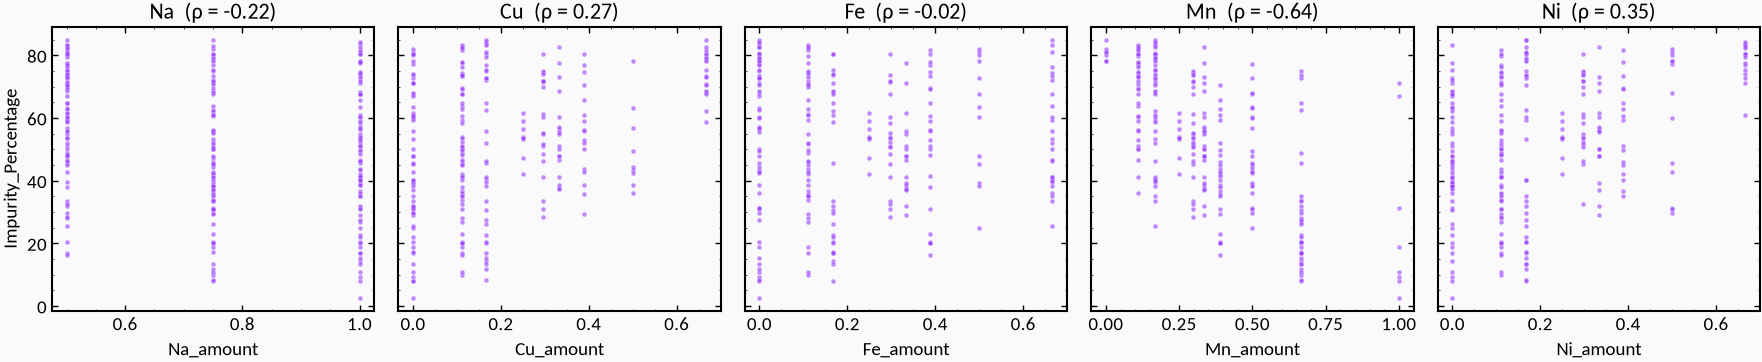

In [15]:
fig = amounts_vs_target(df, IMPURITY)

## Tetrahedral Plots

In [29]:
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.interpolate import griddata

TMS = ["Cu", "Fe", "Mn", "Ni"]
TM_AMOUNTS = [f"{t}_amount" for t in TMS]

# Original colours
IMP_CMAP = plt.cm.RdYlGn_r                     # impurity: green (clean) -> red (impure)
SUCCESS_COLOR = "#00817f"
UNSUCCESS_COLOR = "#e55c30"
EDGE_COLOR = "#2C3E50"
FACE_COLORS = ["#E8F4FD", "#FFF2E8", "#E8F8E8", "#FDE8F4"]
NO_STRUCT_COLOR = "grey"
FAIL_X_COLOR = "#E74C3C"
P2O3_CMAP = LinearSegmentedColormap.from_list(
    "plasma_trunc", plt.cm.plasma(np.linspace(0, 0.93, 256)))

# Shared look - change here and every tetrahedron figure follows
FIG_SIZE = (12, 9)
POINT = dict(s=55, alpha=1.0, edgecolors="white", linewidth=0.6)   # all circles/triangles/squares
CROSS = dict(s=55, alpha=1.0, marker="x", linewidths=2)            # failed syntheses
LEGEND_MS = 8
PANEL_AREA = dict(left=0.03, right=0.6, top=0.90, bottom=0.10)     # same plot area in every figure
CBAR_RECT = [0.62, 0.15, 0.02, 0.7]
LEGEND_ANCHOR = (0.32, 0.01)

TIMES = [12, 6, 3]
NA_VALUES = [1.0, 0.75, 0.5]

_V = {k: v * 5 for k, v in {
    "Cu": np.array([0, 0, np.sqrt(2 / 3)]),
    "Fe": np.array([np.sqrt(8 / 9), 0, -np.sqrt(1 / 6)]),
    "Mn": np.array([-np.sqrt(2 / 9), np.sqrt(2 / 3), -np.sqrt(1 / 6)]),
    "Ni": np.array([-np.sqrt(2 / 9), -np.sqrt(2 / 3), -np.sqrt(1 / 6)]),
}.items()}
_V_MAT = np.vstack([_V[t] for t in TMS])
_LABEL_OFFSETS = {"Cu": (0, 0, 0.8), "Fe": (0.4, 0, -0.85),
                  "Mn": (-0.25, 1.35, -0.15), "Ni": (-0.25, -1.35, -0.15)}


def _tm_fractions(df):
    """Cu/Fe/Mn/Ni amounts normalised to sum to 1 (n x 4 array)."""
    tm = df[TM_AMOUNTS].to_numpy(dtype=float)
    return tm / tm.sum(axis=1, keepdims=True)


def _xyz(df):
    """3D tetrahedron coordinates for each row."""
    return _tm_fractions(df) @ _V_MAT


def _p2o3_category(df):
    """'ok' (ratio >= 0), 'no_structure' (-1), 'failed' (-2, or NaN and not successful)."""
    r = df[RATIO]
    cat = pd.Series("ok", index=df.index)
    cat[r == -1] = "no_structure"
    cat[(r == -2) | (r.isna() & ~df["success"])] = "failed"
    cat[r.isna() & df["success"]] = "missing"
    return cat


def _pts(ax, d, cross=False, **kw):
    """3D scatter with the shared style. depthshade=False stops matplotlib
    fading points by depth (the cause of the washed-out look)."""
    if len(d):
        style = {**(CROSS if cross else POINT), **kw}
        ax.scatter(*_xyz(d).T, depthshade=False, **style)


def _legend_item(marker, color, label):
    if marker == "x":
        return Line2D([0], [0], marker="x", color=color, linestyle="none",
                      markersize=LEGEND_MS, markeredgewidth=2, label=label)
    return Line2D([0], [0], marker=marker, color="w", markerfacecolor=color,
                  markeredgecolor="white", markersize=LEGEND_MS, label=label)


def _add_colorbar(fig, cmap, vmin, vmax, label, invert=False):
    cbar = fig.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax)),
                        cax=fig.add_axes(CBAR_RECT))
    cbar.set_label(label, fontsize=12, fontweight="bold")
    if invert:
        cbar.ax.invert_yaxis()
    return cbar


def _add_legend(fig, items):
    fig.legend(handles=items, loc="lower center", ncol=len(items), fontsize=10,
               bbox_to_anchor=LEGEND_ANCHOR)


def _draw_tetrahedron(ax):
    """Edges, faint faces, vertex labels, limits and view (shared by all panels)."""
    for a, b in [("Cu", "Fe"), ("Cu", "Mn"), ("Cu", "Ni"),
                 ("Fe", "Mn"), ("Fe", "Ni"), ("Mn", "Ni")]:
        ax.plot3D(*zip(_V[a], _V[b]), color=EDGE_COLOR, linewidth=2, alpha=0.7)

    faces = [("Cu", "Fe", "Mn"), ("Cu", "Fe", "Ni"), ("Cu", "Mn", "Ni"), ("Fe", "Mn", "Ni")]
    for face, colour in zip(faces, FACE_COLORS):
        ax.add_collection3d(Poly3DCollection([[_V[v] for v in face]], alpha=0.05,
                                             facecolor=colour, edgecolor="none"))

    for el, pos in _V.items():
        dx, dy, dz = _LABEL_OFFSETS[el]
        ax.text(pos[0] + dx, pos[1] + dy, pos[2] + dz, el, fontsize=12,
                fontweight="bold", color="black", ha="center", va="center")

    ax.set_xlim([-3.6, 3.6])
    ax.set_ylim([-3.6, 3.6])
    ax.set_zlim([-2.3, 3.6])
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.grid(False)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
    ax.view_init(elev=20, azim=10)


def _condition_subset(df, time, na):
    return df[np.isclose(df["Time"], time) & np.isclose(df["Na_amount"], na)]


def _condition_grid(df, panel_fn, times=TIMES, na_values=NA_VALUES):
    """3x3 grid of tetrahedra (rows = Time, cols = Na); panel_fn(ax, subset) draws points."""
    fig = plt.figure(figsize=FIG_SIZE)
    for i, time in enumerate(times):
        for j, na in enumerate(na_values):
            k = i * len(na_values) + j
            ax = fig.add_subplot(len(times), len(na_values), k + 1, projection="3d")
            _draw_tetrahedron(ax)
            sub = _condition_subset(df, time, na)
            if not sub.empty:
                panel_fn(ax, sub)
            ax.set_title(f"({chr(97 + k)}) Time: {time:g} h, Na: {na:g}",
                         fontsize=10, fontweight="bold", pad=5)
    fig.subplots_adjust(wspace=0.001, hspace=0.25, **PANEL_AREA)
    return fig

### Impurity %

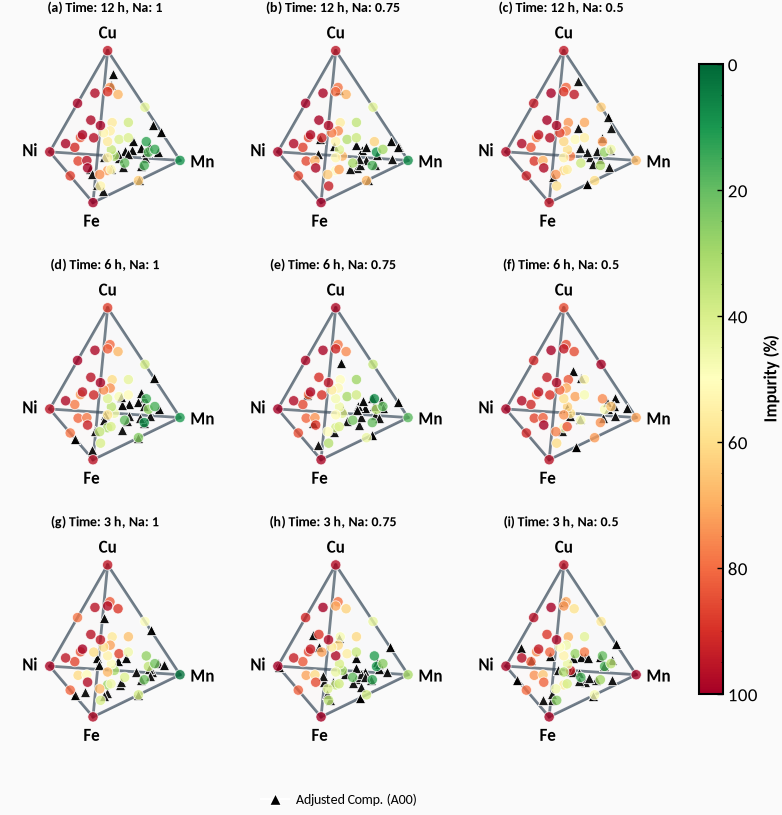

In [38]:
def tetra_impurity(df, show_a00=True, times=TIMES, na_values=NA_VALUES):
    """U00 coloured by impurity (0-100 %, RdYlGn_r); A00 as black triangles."""
    def panel(ax, sub):
        u = sub[sub["is_u00"]]
        _pts(ax, u, c=u[IMPURITY], cmap=IMP_CMAP, vmin=0, vmax=100, zorder=4, alpha = 0.8)
        if show_a00:
            _pts(ax, sub[~sub["is_u00"]], color="k", marker="^", zorder=3)

    fig = _condition_grid(df, panel, times, na_values)
    _add_colorbar(fig, IMP_CMAP, 0, 100, "Impurity (%)", invert=True)   # 100 % at top
    if show_a00:
        _add_legend(fig, [_legend_item("^", "k", "Adjusted Comp. (A00)")])
    return fig


fig = tetra_impurity(df)

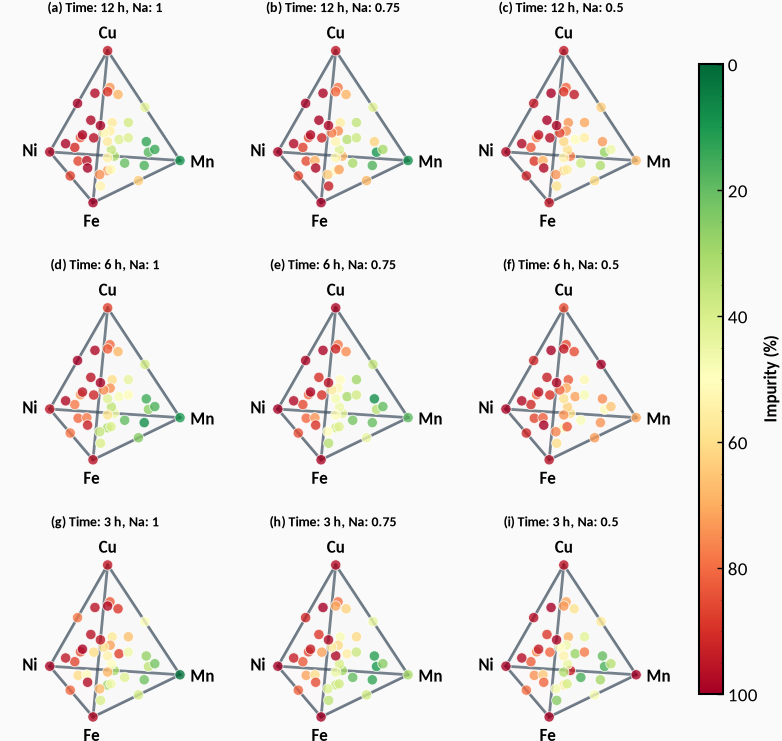

In [39]:
fig = tetra_impurity(df, show_a00=False)

### Synthesizability (Cat_Success)

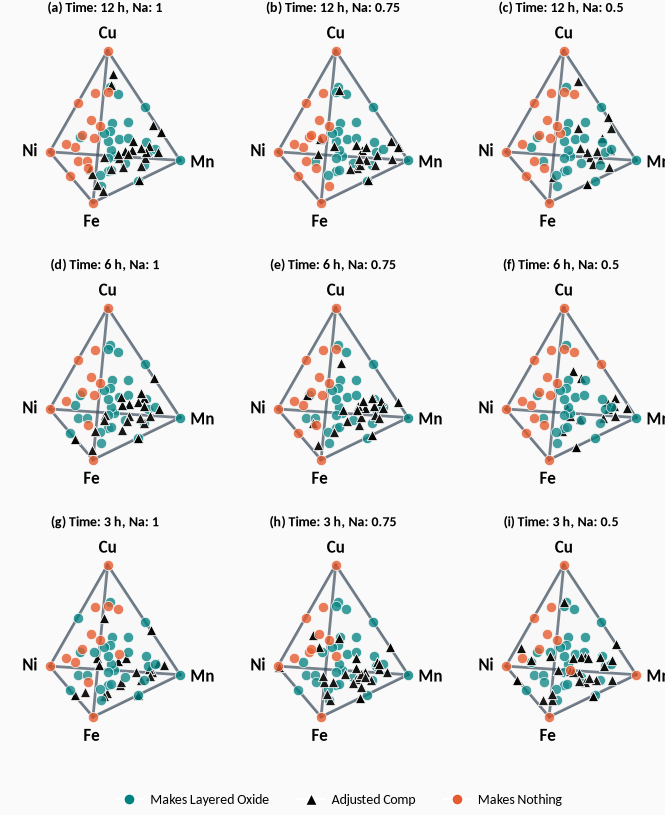

In [40]:
def tetra_success(df, times=TIMES, na_values=NA_VALUES):
    """U00 green (makes layered oxide) / orange (makes nothing); A00 as black triangles."""
    def panel(ax, sub):
        u = sub[sub["is_u00"]]
        _pts(ax, u[u["success"]], color=SUCCESS_COLOR, alpha = 0.8)
        _pts(ax, u[~u["success"]], color=UNSUCCESS_COLOR, alpha = 0.8)
        _pts(ax, sub[~sub["is_u00"]], color="k", marker="^")

    fig = _condition_grid(df, panel, times, na_values)
    _add_legend(fig, [
        _legend_item("o", SUCCESS_COLOR, "Makes Layered Oxide"),
        _legend_item("^", "k", "Adjusted Comp"),
        _legend_item("o", UNSUCCESS_COLOR, "Makes Nothing"),
    ])
    return fig


fig = tetra_success(df)

### P2/O3 ratio

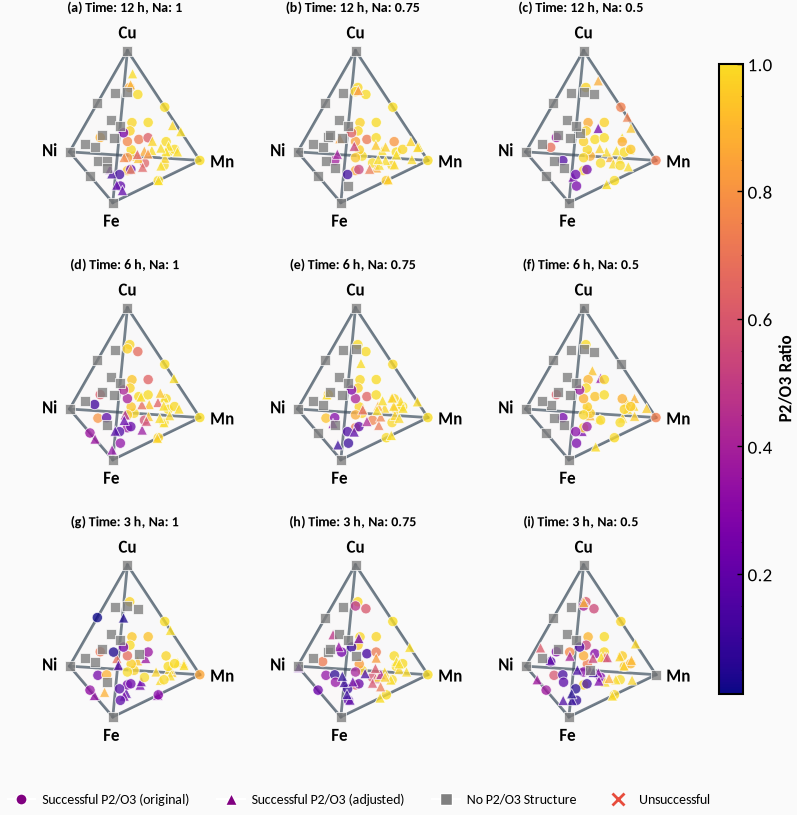

In [41]:
def tetra_p2o3(df, show_a00=True, times=TIMES, na_values=NA_VALUES):
    """Successful points coloured by P2O3ratio (plasma, truncated at 0.93).

    U00 circles, A00 triangles (same colour scale), no P2/O3 structure (-1) as grey
    squares, failed syntheses as red crosses. Colour range is shared across panels.
    """
    data = df if show_a00 else df[df["is_u00"]]
    cat = _p2o3_category(data)
    ok = data.loc[cat == "ok", RATIO]
    vmin, vmax = (ok.min(), ok.max()) if len(ok) else (0, 1)

    def panel(ax, sub):
        c = cat.loc[sub.index]
        good = sub[c == "ok"]
        for d, marker in [(good[good["is_u00"]], "o"), (good[~good["is_u00"]], "^")]:
            _pts(ax, d, c=d[RATIO], marker=marker, cmap=P2O3_CMAP, vmin=vmin, vmax=vmax, alpha = 0.8)
        _pts(ax, sub[c == "no_structure"], color=NO_STRUCT_COLOR, marker="s", alpha = 0.8)
        _pts(ax, sub[c == "failed"], cross=True, color=FAIL_X_COLOR, alpha = 0.8)

    fig = _condition_grid(data, panel, times, na_values)
    _add_colorbar(fig, P2O3_CMAP, vmin, vmax, "P2/O3 Ratio")

    items = [_legend_item("o", "purple", "Successful P2/O3 (original)")]
    if show_a00:
        items.append(_legend_item("^", "purple", "Successful P2/O3 (adjusted)"))
    items += [_legend_item("s", NO_STRUCT_COLOR, "No P2/O3 Structure"),
              _legend_item("x", FAIL_X_COLOR, "Unsuccessful")]
    _add_legend(fig, items)
    return fig


fig = tetra_p2o3(df)

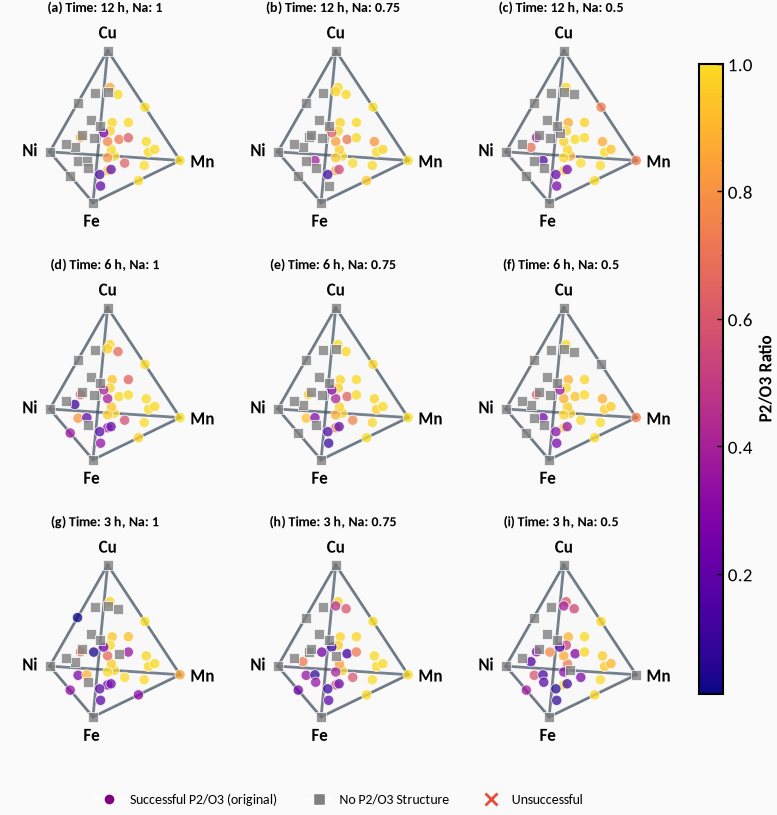

In [42]:
fig = tetra_p2o3(df, show_a00=False)

### P2/O3 ratio on the four tetrahedron faces (one condition)

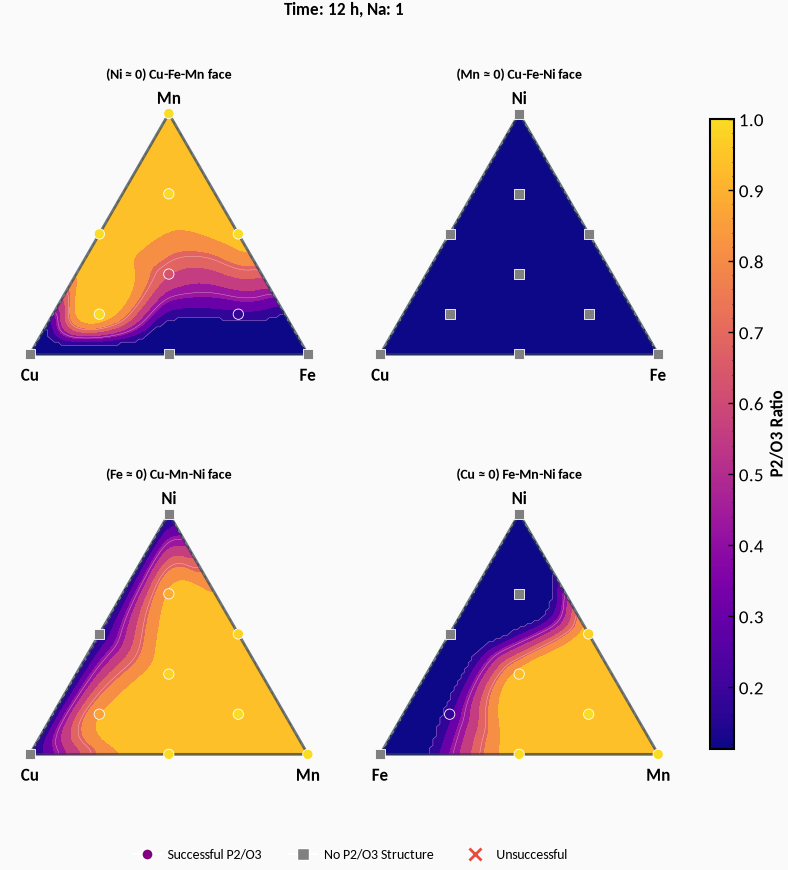

In [35]:
_FACES = [(["Cu", "Fe", "Mn"], "Ni"), (["Cu", "Fe", "Ni"], "Mn"),
          (["Cu", "Mn", "Ni"], "Fe"), (["Fe", "Mn", "Ni"], "Cu")]


def _face_data(df, face_elements, excluded, threshold=0.1):
    """Rows where the excluded TM fraction <= threshold, projected onto that face (x, y)."""
    frac = pd.DataFrame(_tm_fractions(df), columns=TMS, index=df.index)
    keep = frac[excluded] <= threshold
    if keep.sum() < 3:
        return None
    f = frac.loc[keep, face_elements]
    f = f.div(f.sum(axis=1), axis=0)
    out = df.loc[keep].copy()
    out["tri_x"] = f[face_elements[1]] + 0.5 * f[face_elements[2]]
    out["tri_y"] = (np.sqrt(3) / 2) * f[face_elements[2]]
    return out


def _plot_face(ax, face, face_elements, excluded, vmin, vmax, resolution=80, levels=8):
    """Interpolated P2/O3 contour on one face, with the measured points on top."""
    h = np.sqrt(3) / 2
    ax.set_aspect("equal")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, h + 0.1)
    ax.axis("off")
    ax.set_title(f"({excluded} ≈ 0) {'-'.join(face_elements)} face",
                 fontsize=10, fontweight="bold", pad=5)
    ax.plot([0, 1, 0.5, 0], [0, 0, h, 0], color=EDGE_COLOR, linewidth=2, alpha=0.7, zorder=5)
    for (x, y), el, va in zip([(0, -0.05), (1, -0.05), (0.5, h + 0.05)],
                              face_elements, ["top", "top", "center"]):
        ax.text(x, y, el, ha="center", va=va, fontsize=12, fontweight="bold")

    if face is None:
        ax.text(0.5, 0.3, "Insufficient data", ha="center", va="center", fontsize=10)
        return None

    cat = _p2o3_category(face)
    good, nostruct, failed = face[cat == "ok"], face[cat == "no_structure"], face[cat == "failed"]
    used = cat != "missing"

    # grid inside the triangle
    Xi, Yi = np.meshgrid(np.linspace(0, 1, resolution), np.linspace(0, h, resolution))
    tol = 0.001
    mask = (Yi <= np.sqrt(3) * Xi + tol) & (Yi <= np.sqrt(3) * (1 - Xi) + tol) & (Yi >= -tol)

    # failed / no-structure points pull the surface below the colour range
    values = face.loc[used, RATIO].to_numpy(dtype=float).copy()
    floor = (good[RATIO].min() if len(good) else 0) - 0.9 * (vmax - vmin)
    values[cat[used].isin(["no_structure", "failed"]).to_numpy()] = floor

    contour = None
    try:
        zi = griddata((face.loc[used, "tri_x"], face.loc[used, "tri_y"]), values,
                      (Xi[mask], Yi[mask]), method="cubic", fill_value=np.nan)
        grid = np.full(Xi.shape, np.nan)
        grid[mask] = zi
        grid = np.clip(grid, vmin, vmax)
        lo = min(vmin, np.nanmin(grid)) if np.isfinite(np.nanmin(grid)) else vmin
        contour = ax.contourf(Xi, Yi, grid, levels=np.linspace(lo, vmax, levels),
                              cmap=P2O3_CMAP, vmin=lo, vmax=vmax, extend="min")
        ax.contour(Xi, Yi, grid, levels=np.linspace(lo, vmax, levels // 2),
                   colors="white", linewidths=0.3, alpha=0.6)
    except Exception as e:
        print(f"Contour failed for {excluded} = 0 face: {e}")

    if len(good):
        ax.scatter(good["tri_x"], good["tri_y"], c=good[RATIO], cmap=P2O3_CMAP,
                   vmin=vmin, vmax=vmax, zorder=20, **POINT)
    if len(nostruct):
        ax.scatter(nostruct["tri_x"], nostruct["tri_y"], color=NO_STRUCT_COLOR, marker="s",
                   zorder=20, **POINT)
    if len(failed):
        ax.scatter(failed["tri_x"], failed["tri_y"], color=FAIL_X_COLOR, zorder=20, **CROSS)
    return contour


def tetra_faces_p2o3(df, time=12, na=1.0, threshold=0.1, u00_only=True):
    """2x2 triangular contour plots of P2O3ratio, one per tetrahedron face."""
    data = df[df["is_u00"]] if u00_only else df
    sub = _condition_subset(data, time, na)
    if sub.empty:
        print(f"No data for Time = {time}, Na = {na}")
        return None

    ok = sub.loc[_p2o3_category(sub) == "ok", RATIO]
    vmin, vmax = (ok.min(), ok.max()) if len(ok) else (0, 1)

    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE)
    for ax, (elements, excluded) in zip(axes.flat, _FACES):
        _plot_face(ax, _face_data(sub, elements, excluded, threshold),
                   elements, excluded, vmin, vmax)
    fig.subplots_adjust(wspace=0.05, hspace=0.25, **PANEL_AREA)
    fig.suptitle(f"Time: {time:g} h, Na: {na:g}", fontsize=12, fontweight="bold",
                 x=(PANEL_AREA["left"] + PANEL_AREA["right"]) / 2)

    _add_colorbar(fig, P2O3_CMAP, vmin, vmax, "P2/O3 Ratio")
    _add_legend(fig, [
        _legend_item("o", "purple", "Successful P2/O3"),
        _legend_item("s", NO_STRUCT_COLOR, "No P2/O3 Structure"),
        _legend_item("x", FAIL_X_COLOR, "Unsuccessful"),
    ])
    return fig


fig = tetra_faces_p2o3(df, time=12, na=1.0)